In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

rfm_log = pd.read_csv(
    "../results/customer_rfm_log.csv"
)

rfm = pd.read_csv(
    "../results/customer_rfm.csv"
)

rfm_log.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,5.789960,2.564949,11.258774
1,12347.0,1.098612,2.197225,8.501578
2,12348.0,4.330733,1.791759,7.611051
3,12349.0,2.995732,1.609438,8.396085
4,12350.0,5.739793,0.693147,5.815324


In [2]:
X = rfm_log[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.85670058,  1.25449595,  3.20621937],
       [-2.15197903,  0.80016603,  1.21599349],
       [-0.07913835,  0.29920733,  0.57318471],
       [-0.93530818,  0.07394609,  1.13984551],
       [ 0.82452706, -1.05814595, -0.72302406]])

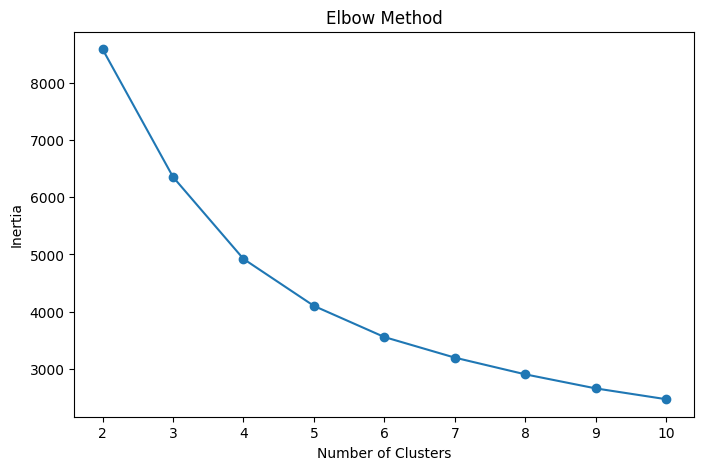

In [3]:
#Elbow Method
inertia = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [4]:
#Silhouette Score
from sklearn.metrics import silhouette_score


for k in range(2,9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(
        f"K={k}: {score:.3f}"
    )

K=2: 0.439
K=3: 0.348
K=4: 0.365
K=5: 0.342
K=6: 0.335
K=7: 0.307
K=8: 0.303


In [5]:
#Train K-means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

rfm["Cluster"] = clusters
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,12,77556.46,2
1,12347.0,2,8,4921.53,2
2,12348.0,75,5,2019.40,3
3,12349.0,19,4,4428.69,1
4,12350.0,310,1,334.40,0


In [6]:
#Analyze Segments
cluster_summary = rfm.groupby("Cluster").agg(
    {
        "Recency":"mean",
        "Frequency":"mean",
        "Monetary":"mean",
        "Customer ID":"count"
    }
)

cluster_summary.rename(
    columns={
        "Customer ID":"Customer Count"
    },
    inplace=True
)

cluster_summary

,Recency,Frequency,Monetary,Customer Count
Cluster,,,,
0,394.946275,1.377598,317.081501,1973
1,28.304800,3.053600,857.491434,1250
2,27.711538,19.275920,10731.162991,1196
3,230.072653,5.058259,1948.503933,1459


In [7]:
cluster_names = {
    0: "Inactive Customers", # Haven't purchased in over a year, Usually only bought once, Low spending
    1: "New & Growing Customers", # Recently purchased, Some repeat purchases, Lower spending
    2: "VIP Customers", # Recent buyers, Purchase frequently, Spend a lot
    3: "At-Risk Valuable Customers" #More purchases than Cluster 1, Higher spending than Cluster 1, They have not purchased recently
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

In [8]:
rfm.to_csv(
    "../results/customer_segments.csv",
    index=False
)

cluster_summary.to_csv(
    "../results/cluster_summary.csv"
)

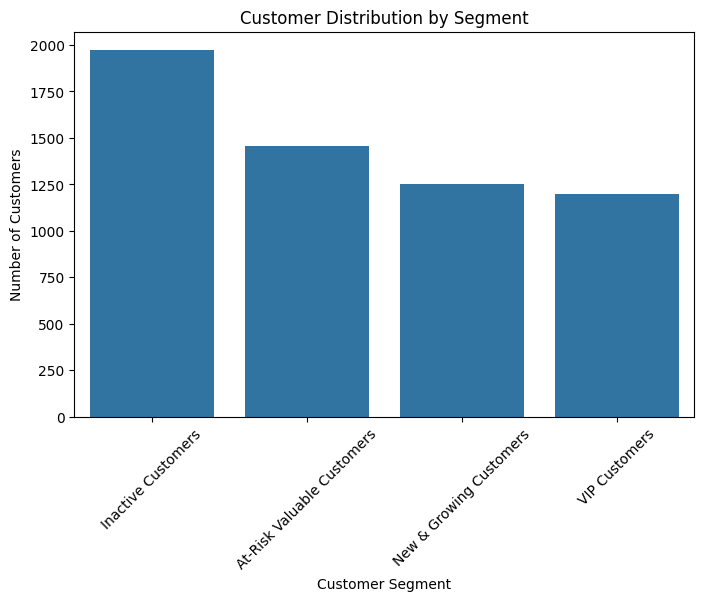

In [9]:
#Segment Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x="Segment",
    order=rfm["Segment"].value_counts().index
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

In [10]:
segment_summary = rfm.groupby("Segment").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
}).reset_index()

segment_summary

,Segment,Recency,Frequency,Monetary
0,At-Risk Valuable Customers,230.072653,5.058259,1948.503933
1,Inactive Customers,394.946275,1.377598,317.081501
2,New & Growing Customers,28.304800,3.053600,857.491434
3,VIP Customers,27.711538,19.275920,10731.162991


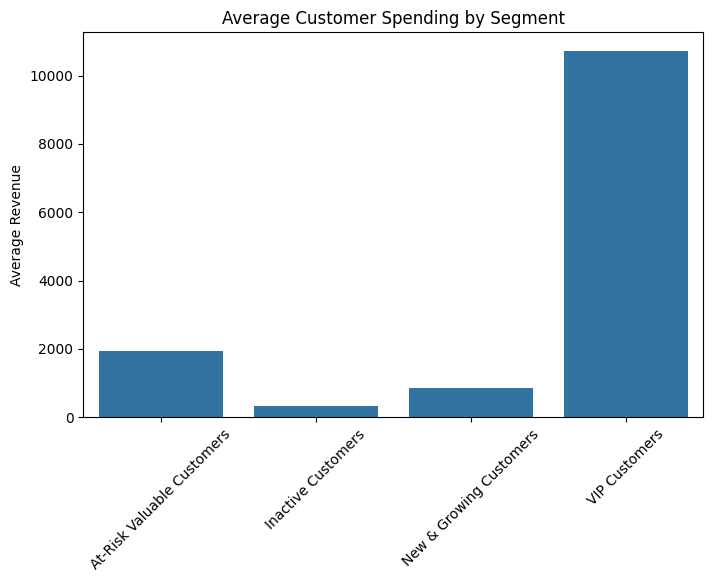

In [11]:
#Monetary Segments
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_summary,
    x="Segment",
    y="Monetary"
)

plt.title("Average Customer Spending by Segment")
plt.xlabel("")
plt.ylabel("Average Revenue")

plt.xticks(rotation=45)

plt.show()

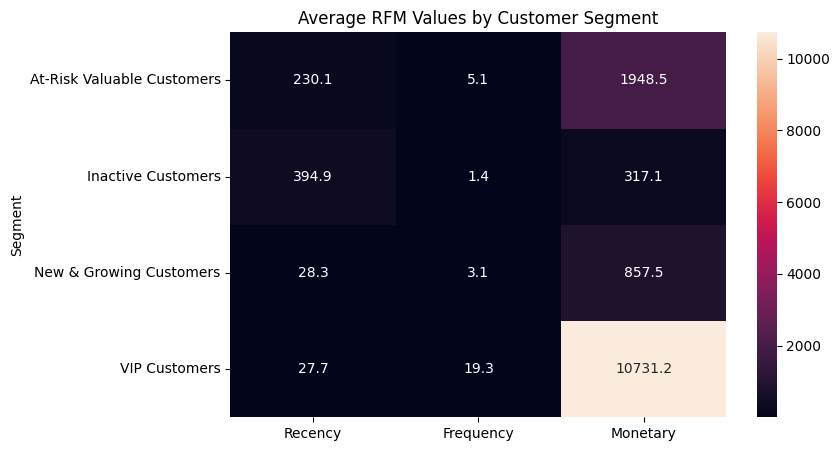

In [12]:
#Heatmap
heatmap_data = segment_summary.set_index("Segment")

plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f"
)

plt.title("Average RFM Values by Customer Segment")

plt.show()

In [13]:
#Normalized Heatmap

rfm_heatmap = segment_summary.copy()

# Scale values from 0 to 1
scaler = MinMaxScaler()

rfm_heatmap[
    ["Recency", "Frequency", "Monetary"]
] = scaler.fit_transform(
    rfm_heatmap[
        ["Recency", "Frequency", "Monetary"]
    ]
)

# Reverse Recency
rfm_heatmap["Recency"] = 1 - rfm_heatmap["Recency"]

#Segment as index
rfm_heatmap = rfm_heatmap.set_index("Segment")

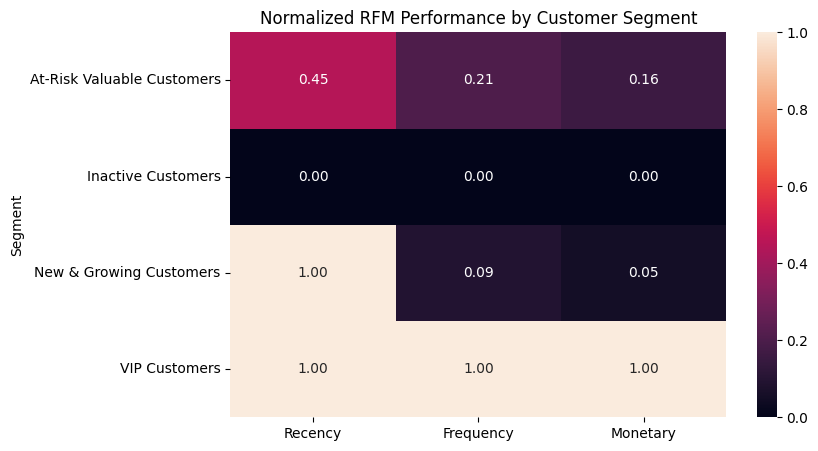

In [14]:
plt.figure(figsize=(8,5))

sns.heatmap(
    rfm_heatmap[
        ["Recency", "Frequency", "Monetary"]
    ],
    annot=True,
    fmt=".2f"
)

plt.title("Normalized RFM Performance by Customer Segment")

plt.show()

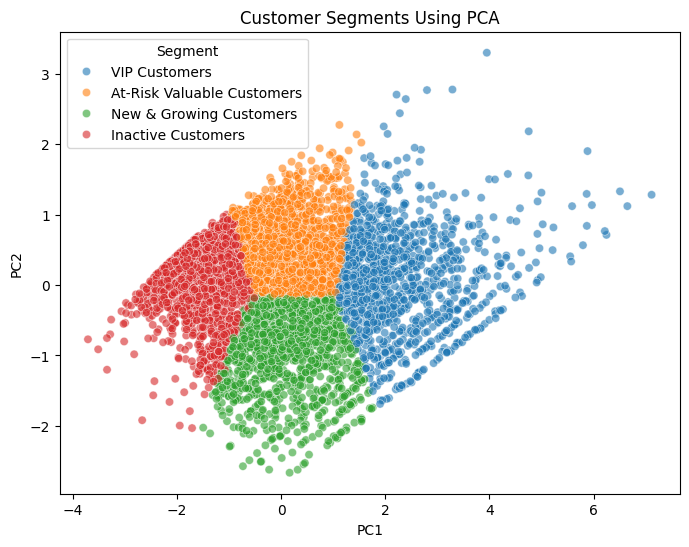

In [15]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1","PC2"]
)

pca_df["Segment"] = rfm["Segment"].values

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Segment",
    alpha=0.6
)

plt.title("Customer Segments Using PCA")
plt.show()

In [16]:
rfm.to_csv(
    "../results/customer_segments.csv",
    index=False
)

In [17]:
segment_strategy = pd.DataFrame({
    "Segment": [
        "VIP Customers",
        "New & Growing Customers",
        "At-Risk Valuable Customers",
        "Inactive Customers"
    ],
    "Characteristics": [
        "Recent, frequent, high spending",
        "Recent customers with growth potential",
        "Previously valuable but declining activity",
        "Low activity and low spending"
    ],
    "Strategy": [
        "Rewards, loyalty programs, exclusive offers",
        "Upselling and product recommendations",
        "Win-back campaigns and personalized discounts",
        "Re-engagement campaigns"
    ]
})

segment_strategy.to_csv(
    "../results/segment_strategy.csv",
    index=False
)

segment_strategy

,Segment,Characteristics,Strategy
0,VIP Customers,"Recent, frequent, high spending","Rewards, loyalty programs, exclusive offers"
1,New & Growing Customers,Recent customers with growth potential,Upselling and product recommendations
2,At-Risk Valuable Customers,Previously valuable but declining activity,Win-back campaigns and personalized discounts
3,Inactive Customers,Low activity and low spending,Re-engagement campaigns
